# Banking Fraud Detection & Risk Analytics Workflow

Created by Hieu Nguyen

This notebook documents the full analytical workflow used in the professional report and dashboard:

- Data loading and clean up
- Exploratory Data Analysis (EDA)
- Fraud detection classification models
- Risk scoring systems
- Predictive analytics scenario scoring
- Classification and anomaly detection
- Financial analytics and exposure review

## 1. Setup

Run this notebook with the `.bankingvenv` environment. If you are using VS Code or Jupyter, select the `Banking Risk Analytics` kernel after installing dependencies.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

## 2. Load Data

The notebook can run from either the project root or the `notebooks` folder.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "banking_transactions.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "banking_transactions.csv"
raw_df = pd.read_csv(DATA_PATH)

print(f"Data path: {DATA_PATH}")
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} columns")
raw_df.head()

Data path: c:\Users\hieum\Desktop\Repo\Banking Fraud Detection & Risk Analytics\Banking_Fraud_Detection_ and_ Risk_ Analytics\banking_transactions.csv
Shape: 10,000 rows x 20 columns


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


## 3. Clean Up Data

Cleaning steps:

- Standardize column names.
- Remove duplicate transaction IDs.
- Convert fraud and flag fields to clean boolean/integer types.
- Clean categorical text fields.
- Validate numeric ranges and clip bounded scores where appropriate.
- Add analytical labels used by EDA, modeling, and risk scoring.

In [3]:
def clean_banking_transactions(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned.columns = (
        cleaned.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    before_rows = len(cleaned)
    cleaned = cleaned.drop_duplicates(subset="transaction_id", keep="first")
    removed_duplicates = before_rows - len(cleaned)

    cleaned["fraud_flag"] = cleaned["fraud_flag"].astype(str).str.upper().map({"TRUE": True, "FALSE": False})
    flag_columns = ["card_present_flag", "international_transaction_flag", "suspicious_ip_flag"]
    for column in flag_columns:
        cleaned[column] = cleaned[column].astype(int).clip(0, 1)

    categorical_columns = ["payment_channel", "authentication_type"]
    for column in categorical_columns:
        cleaned[column] = cleaned[column].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

    numeric_columns = cleaned.select_dtypes(include="number").columns
    cleaned[numeric_columns] = cleaned[numeric_columns].apply(pd.to_numeric, errors="coerce")

    cleaned["transaction_amount"] = cleaned["transaction_amount"].clip(lower=0)
    cleaned["anomaly_score"] = cleaned["anomaly_score"].clip(0, 1)
    cleaned["device_risk_score"] = cleaned["device_risk_score"].clip(0, 100)
    cleaned["transaction_velocity_score"] = cleaned["transaction_velocity_score"].clip(0, 100)
    cleaned["transaction_time_hour"] = cleaned["transaction_time_hour"].clip(0, 23).astype(int)

    if cleaned.isna().any().any():
        numeric_columns = cleaned.select_dtypes(include="number").columns
        cleaned[numeric_columns] = cleaned[numeric_columns].fillna(cleaned[numeric_columns].median())
        for column in categorical_columns:
            cleaned[column] = cleaned[column].fillna(cleaned[column].mode().iloc[0])
        cleaned["fraud_flag"] = cleaned["fraud_flag"].fillna(False)

    cleaned["fraud_label"] = np.where(cleaned["fraud_flag"], "Fraud", "Legitimate")
    print(f"Removed duplicate transaction IDs: {removed_duplicates:,}")
    print(f"Missing values after clean up: {int(cleaned.isna().sum().sum()):,}")
    return cleaned

df = clean_banking_transactions(raw_df)
df.info()

Removed duplicate transaction IDs: 0
Missing values after clean up: 0
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 100

## 4. Exploratory Data Analysis (EDA)

This section summarizes portfolio size, class balance, financial volume, channel behavior, authentication behavior, and time-of-day patterns.

In [4]:
summary = pd.Series({
    "transactions": len(df),
    "columns": df.shape[1],
    "missing_values": int(df.isna().sum().sum()),
    "fraud_transactions": int(df["fraud_flag"].sum()),
    "legitimate_transactions": int((~df["fraud_flag"]).sum()),
    "fraud_rate": df["fraud_flag"].mean(),
    "total_volume": df["transaction_amount"].sum(),
    "confirmed_fraud_value": df.loc[df["fraud_flag"], "transaction_amount"].sum(),
})
summary

transactions               1.000000e+04
columns                    2.100000e+01
missing_values             0.000000e+00
fraud_transactions         1.251000e+03
legitimate_transactions    8.749000e+03
fraud_rate                 1.251000e-01
total_volume               1.241275e+08
confirmed_fraud_value      1.565740e+07
dtype: float64

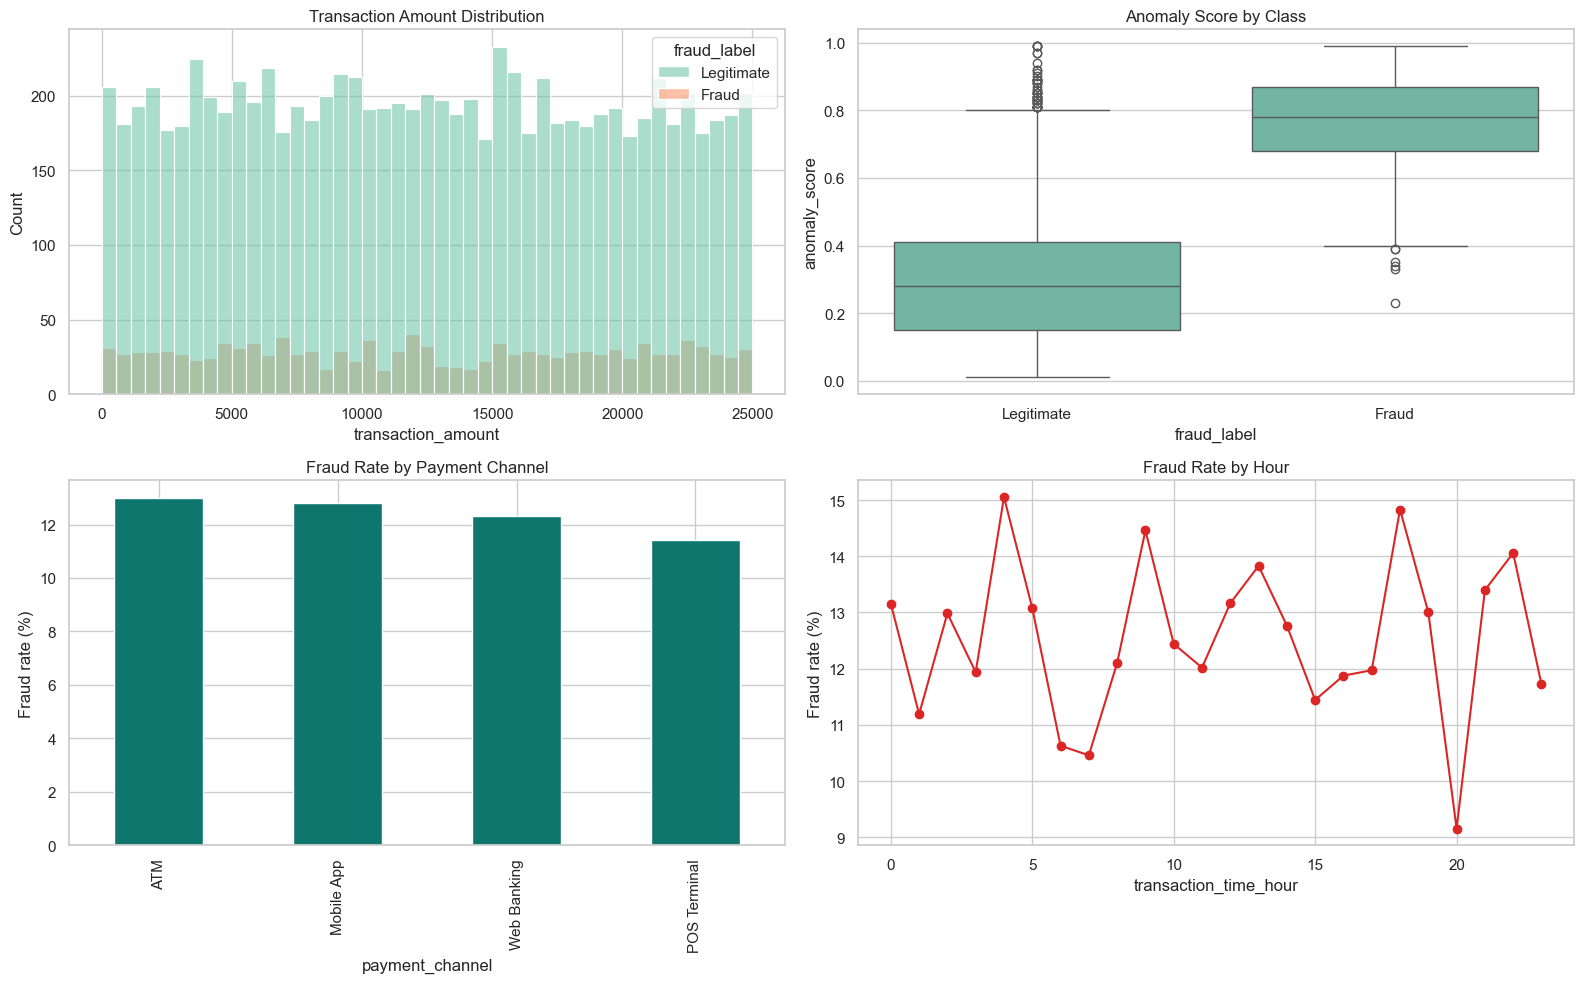

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(data=df, x="transaction_amount", hue="fraud_label", bins=45, alpha=0.55, ax=axes[0, 0])
axes[0, 0].set_title("Transaction Amount Distribution")

sns.boxplot(data=df, x="fraud_label", y="anomaly_score", ax=axes[0, 1])
axes[0, 1].set_title("Anomaly Score by Class")

channel_rate = df.groupby("payment_channel")["fraud_flag"].mean().sort_values(ascending=False)
channel_rate.mul(100).plot(kind="bar", ax=axes[1, 0], color="#0f766e")
axes[1, 0].set_title("Fraud Rate by Payment Channel")
axes[1, 0].set_ylabel("Fraud rate (%)")

hourly_rate = df.groupby("transaction_time_hour")["fraud_flag"].mean().mul(100)
hourly_rate.plot(kind="line", marker="o", ax=axes[1, 1], color="#dc2626")
axes[1, 1].set_title("Fraud Rate by Hour")
axes[1, 1].set_ylabel("Fraud rate (%)")

plt.tight_layout()

In [6]:
channel_summary = (
    df.groupby("payment_channel")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_rate=("fraud_flag", "mean"),
        total_amount=("transaction_amount", "sum"),
        fraud_amount=("transaction_amount", lambda s: s[df.loc[s.index, "fraud_flag"]].sum()),
    )
    .sort_values("fraud_rate", ascending=False)
)

auth_summary = (
    df.groupby("authentication_type")
    .agg(transactions=("transaction_id", "count"), fraud_rate=("fraud_flag", "mean"))
    .sort_values("fraud_rate", ascending=False)
)

display(channel_summary)
display(auth_summary)

,transactions,fraud_rate,total_amount,fraud_amount
payment_channel,,,,
ATM,777,0.129987,9488029.06,1193292.38
Mobile App,4804,0.128226,59583527.58,7711462.29
Web Banking,3247,0.123191,40261014.31,5038341.90
POS Terminal,1172,0.114334,14794969.09,1714307.64


,transactions,fraud_rate
authentication_type,,
OTP,4214,0.130755
Password Only,1817,0.127683
Biometric,1585,0.120505
Two-Factor Authentication,2384,0.116191


## 5. Risk Scoring Systems

The dashboard uses a transparent weighted risk score from 0 to 100. This score helps prioritize review queues even before a supervised model is deployed.

In [7]:
def normalize(series: pd.Series, lower_q: float = 0.01, upper_q: float = 0.99) -> pd.Series:
    lo = float(series.quantile(lower_q))
    hi = float(series.quantile(upper_q))
    clipped = series.clip(lo, hi)
    return (clipped - lo) / (hi - lo) if hi != lo else pd.Series(0, index=series.index)


def add_risk_score(data: pd.DataFrame) -> pd.DataFrame:
    scored = data.copy()
    components = {
        "anomaly_score": 0.36,
        "device_risk_score": 0.12,
        "transaction_velocity_score": 0.12,
        "failed_transactions_last_30d": 0.10,
        "login_attempts": 0.08,
        "geo_distance_km": 0.07,
        "transaction_amount": 0.06,
        "suspicious_ip_flag": 0.04,
        "international_transaction_flag": 0.03,
    }
    score = pd.Series(np.zeros(len(scored)), index=scored.index, dtype=float)
    for column, weight in components.items():
        if column in {"anomaly_score", "suspicious_ip_flag", "international_transaction_flag"}:
            component = scored[column].astype(float)
        else:
            component = normalize(scored[column].astype(float))
        score += component * weight
    score += (1 - scored["card_present_flag"].astype(float)) * 0.02

    scored["risk_score"] = (score * 100).clip(0, 100).round(1)
    scored["risk_tier"] = pd.cut(
        scored["risk_score"],
        bins=[-0.1, 35, 55, 75, 100.1],
        labels=["Low", "Watch", "High", "Critical"],
    ).astype(str)
    scored["expected_loss"] = (scored["transaction_amount"] * scored["risk_score"] / 100).round(2)
    return scored


df = add_risk_score(df)
df[["risk_score", "risk_tier", "expected_loss"]].describe(include="all")

,risk_score,risk_tier,expected_loss
count,10000.00000,10000,10000.000000
unique,NaN,4,NaN
top,NaN,Watch,NaN
freq,NaN,6210,NaN
mean,44.57212,NaN,5663.377193
std,11.35867,NaN,3817.219604
min,7.70000,NaN,1.520000
25%,36.60000,NaN,2495.717500
50%,43.90000,NaN,5162.240000
75%,51.80000,NaN,8274.222500


In [8]:
risk_summary = (
    df.groupby("risk_tier")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_rate=("fraud_flag", "mean"),
        total_amount=("transaction_amount", "sum"),
        expected_loss=("expected_loss", "sum"),
    )
    .reindex(["Low", "Watch", "High", "Critical"])
)
risk_summary

,transactions,fraud_rate,total_amount,expected_loss
risk_tier,,,,
Low,2051,0.001463,22315489.11,6662899.05
Watch,6210,0.064895,77581741.55,34825827.54
High,1678,0.470203,23258536.96,14385529.51
Critical,61,0.918033,971772.42,759515.83


## 6. Fraud Detection Models

We train two supervised classifiers with a stratified 75/25 holdout split. PR-AUC is prioritized because fraud detection is an imbalanced classification problem.

In [9]:
target = df["fraud_flag"].astype(int)
features = df.drop(columns=["fraud_flag", "fraud_label", "risk_score", "risk_tier", "expected_loss", "transaction_id"])

numeric_features = features.select_dtypes(include="number").columns.tolist()
categorical_features = features.select_dtypes(exclude="number").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.25,
    stratify=target,
    random_state=RANDOM_STATE,
)

def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )


models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

results = []
trained_models = {}
for model_name, estimator in models.items():
    pipeline = Pipeline([("preprocess", make_preprocessor()), ("model", estimator)])
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, probabilities)
    f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    threshold = float(thresholds[min(best_idx, len(thresholds) - 1)])
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    results.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(y_test, probabilities),
        "threshold": threshold,
        "precision": precision[best_idx],
        "recall": recall[best_idx],
        "f1": f1_scores[best_idx],
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })
    trained_models[model_name] = pipeline

model_results = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
model_results

,model,roc_auc,pr_auc,threshold,precision,recall,f1,tn,fp,fn,tp
0,Logistic Regression,0.978317,0.867798,0.822515,0.801829,0.840256,0.820593,2122,65,50,263
1,Random Forest,0.972198,0.812138,0.717577,0.774481,0.833866,0.803077,2111,76,52,261


Champion model: Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.98      0.97      0.97      2187
       Fraud       0.80      0.84      0.82       313

    accuracy                           0.95      2500
   macro avg       0.89      0.91      0.90      2500
weighted avg       0.96      0.95      0.95      2500



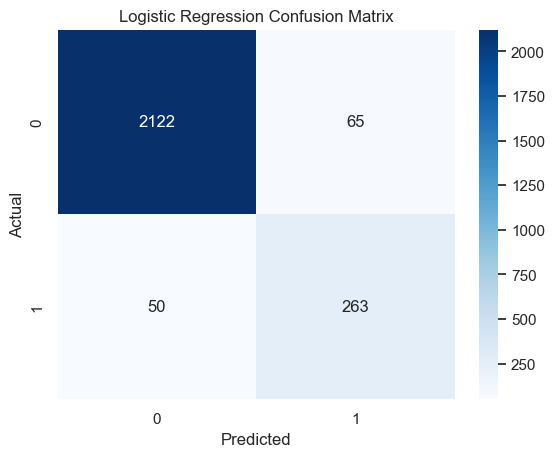

In [10]:
champion_name = model_results.iloc[0]["model"]
champion = trained_models[champion_name]
champion_probability = champion.predict_proba(X_test)[:, 1]
champion_threshold = float(model_results.iloc[0]["threshold"])
champion_prediction = (champion_probability >= champion_threshold).astype(int)

print(f"Champion model: {champion_name}")
print(classification_report(y_test, champion_prediction, target_names=["Legitimate", "Fraud"]))

sns.heatmap(confusion_matrix(y_test, champion_prediction), annot=True, fmt="d", cmap="Blues")
plt.title(f"{champion_name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. Classification & Anomaly Detection

Isolation Forest provides an unsupervised anomaly signal. It is not a replacement for supervised classification on this labeled dataset, but it is useful as a secondary monitoring control.

In [11]:
isolation_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", IsolationForest(
        n_estimators=250,
        contamination=float(target.mean()),
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

isolation_model.fit(X_train[numeric_features])
anomaly_scores = -isolation_model.decision_function(X_test[numeric_features])

pd.DataFrame([{
    "method": "Isolation Forest",
    "roc_auc": roc_auc_score(y_test, anomaly_scores),
    "pr_auc": average_precision_score(y_test, anomaly_scores),
}])

,method,roc_auc,pr_auc
0,Isolation Forest,0.711002,0.293532


## 8. Predictive Analytics Scenario

This cell scores a new transaction with both the champion classifier and the transparent risk scoring system.

In [12]:
scenario = pd.DataFrame([{
    "transaction_amount": 18500.00,
    "login_attempts": 7,
    "device_risk_score": 82.0,
    "transfer_frequency": 65,
    "anomaly_score": 0.86,
    "account_age_days": 420,
    "transaction_time_hour": 22,
    "failed_transactions_last_30d": 18,
    "avg_monthly_balance": 54000.0,
    "daily_transaction_count": 42,
    "geo_distance_km": 9500,
    "session_duration_minutes": 8,
    "transaction_velocity_score": 88.0,
    "payment_channel": "Web Banking",
    "authentication_type": "Password Only",
    "card_present_flag": 0,
    "international_transaction_flag": 1,
    "suspicious_ip_flag": 1,
}])

probability = champion.predict_proba(scenario)[0, 1]
scenario_for_risk = scenario.assign(transaction_id=-1, fraud_flag=False, fraud_label="Scenario")
risk_reference = pd.concat([
    df.drop(columns=["risk_score", "risk_tier", "expected_loss"], errors="ignore"),
    scenario_for_risk,
], ignore_index=True)
scenario_risk = add_risk_score(risk_reference).tail(1)

pd.DataFrame([{
    "champion_model": champion_name,
    "fraud_probability": probability,
    "risk_score": float(scenario_risk["risk_score"].iloc[0]),
    "risk_tier": scenario_risk["risk_tier"].iloc[0],
}])

,champion_model,fraud_probability,risk_score,risk_tier
0,Logistic Regression,0.991539,80.8,Critical


## 9. Financial Analytics Projects

Financial analytics converts model output into business exposure views: expected loss, channel exposure, high-risk review queues, and portfolio prioritization.

In [13]:
financial_summary = (
    df.groupby(["payment_channel", "authentication_type"])
    .agg(
        transactions=("transaction_id", "count"),
        total_amount=("transaction_amount", "sum"),
        fraud_rate=("fraud_flag", "mean"),
        expected_loss=("expected_loss", "sum"),
    )
    .sort_values("expected_loss", ascending=False)
)

high_risk_queue = df[df["risk_score"] >= 75].sort_values(["risk_score", "transaction_amount"], ascending=False)
print(f"High-risk review queue: {len(high_risk_queue):,} transactions")
print(f"Expected exposure in queue: ${high_risk_queue['expected_loss'].sum():,.2f}")

display(financial_summary.head(10))
high_risk_queue[[
    "transaction_id",
    "transaction_amount",
    "payment_channel",
    "authentication_type",
    "anomaly_score",
    "risk_score",
    "risk_tier",
    "expected_loss",
    "fraud_label",
]].head(15)

High-risk review queue: 62 transactions
Expected exposure in queue: $776,187.39


transactions  total_amount  \
payment_channel authentication_type                                     
Mobile App      OTP                                1999   25437856.52   
Web Banking     OTP                                1384   17221195.10   
Mobile App      Two-Factor Authentication          1143   13852437.88   
                Password Only                       882   10873504.68   
Web Banking     Two-Factor Authentication           787    9739773.60   
Mobile App      Biometric                           780    9419728.50   
Web Banking     Password Only                       581    7233330.58   
                Biometric                           495    6066715.03   
POS Terminal    OTP                                 482    5914084.82   
ATM             OTP                                 349    4309394.07   

                                           fraud_rate  expected_loss  
payment_channel authentication_type                                   
Mobile App      OTP                          0.133067    11693873.63  
Web Banking     OTP                          0.125000     7858405.42  
Mobile App      Two-Factor Authentication    0.121610     6336373.66  
                Password Only                0.130385     5016876.38  
Web Banking     Two-Factor Authentication    0.113088     4380809.15  
Mobile App      Biometric                    0.123077     4306201.58  
Web Banking     Password Only                0.135972     3278142.08  
                Biometric                    0.119192     2739132.34  
POS Terminal    OTP                          0.128631     2671108.82  
ATM             OTP                          0.143266     1972585.97

,transaction_id,transaction_amount,payment_channel,authentication_type,anomaly_score,risk_score,risk_tier,expected_loss,fraud_label
1842,1001843,22854.87,Mobile App,Two-Factor Authentication,0.99,88.8,Critical,20295.12,Fraud
3924,1003925,18213.40,Web Banking,OTP,0.89,85.6,Critical,15590.67,Fraud
1177,1001178,19879.36,POS Terminal,Password Only,0.99,85.2,Critical,16937.21,Fraud
2162,1002163,12606.34,Mobile App,OTP,0.99,85.2,Critical,10740.60,Fraud
2665,1002666,13766.06,Mobile App,Biometric,0.99,82.4,Critical,11343.23,Fraud
903,1000904,15939.30,POS Terminal,Password Only,0.99,81.9,Critical,13054.29,Fraud
2003,1002004,4148.58,Mobile App,OTP,0.94,81.9,Critical,3397.69,Fraud
2072,1002073,24128.30,Web Banking,Two-Factor Authentication,0.92,81.7,Critical,19712.82,Fraud
6140,1006141,24439.14,Web Banking,OTP,0.89,81.2,Critical,19844.58,Fraud
7323,1007324,16124.15,POS Terminal,OTP,0.92,81.2,Critical,13092.81,Fraud


## 10. Dashboard Development Notes

The same workflow is implemented in `dashboard.py` as an interactive Streamlit application with filters, KPI cards, Plotly charts, model metrics, risk scoring, predictive scoring, and financial exposure analytics.

Run the dashboard from the project root:

```powershell
streamlit run dashboard.py
```

Created by Hieu Nguyen